In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning models
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report


In [2]:
# Load the dataset
data = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Show first 5 rows
data.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# Check column names, data types, and non-null counts
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
# Basic statistics of numeric columns
data.describe()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [5]:
# Count missing values per column
data.isnull().sum()


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
# Drop the 'id' column
data.drop('id', axis=1, inplace=True)

# Fill missing BMI values with median
data['bmi'].fillna(data['bmi'].median(), inplace=True)

# Verify missing values are gone
data.isnull().sum()


C:\Users\ghady\AppData\Local\Temp\ipykernel_8948\2998664916.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bmi'].fillna(data['bmi'].median(), inplace=True)


gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [7]:
# Columns to encode
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Convert text to numbers
le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Check first 5 rows
data.head()


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


In [8]:
# Columns to scale
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# Check first 5 rows after scaling
data.head()


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,1.051434,0,1,1,2,1,2.706375,1.005086,1,1
1,0,0.786070,0,0,1,3,0,2.121559,-0.098981,2,1
2,1,1.626390,0,1,1,2,0,-0.005028,0.472536,2,1
3,0,0.255342,0,0,1,2,1,1.437358,0.719327,3,1
4,0,1.582163,1,0,1,3,0,1.501184,-0.631531,2,1


In [9]:
# Separate features and target
X = data.drop('stroke', axis=1)  # all columns except target
y = data['stroke']               # target column

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (4088, 10)
X_test shape: (1022, 10)
y_train shape: (4088,)
y_test shape: (1022,)


In [10]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Accuracy: 0.9481409001956947


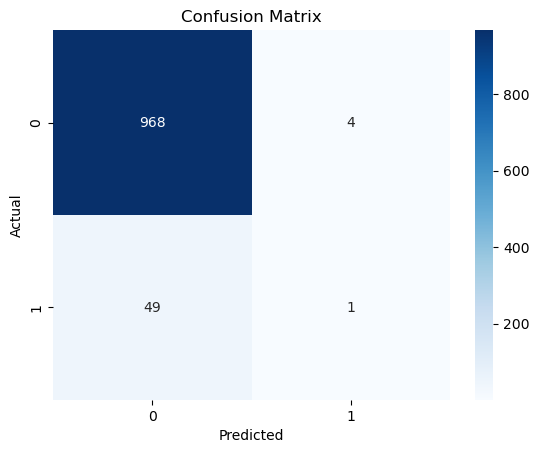

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.20      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.58      0.51      0.50      1022
weighted avg       0.92      0.95      0.93      1022



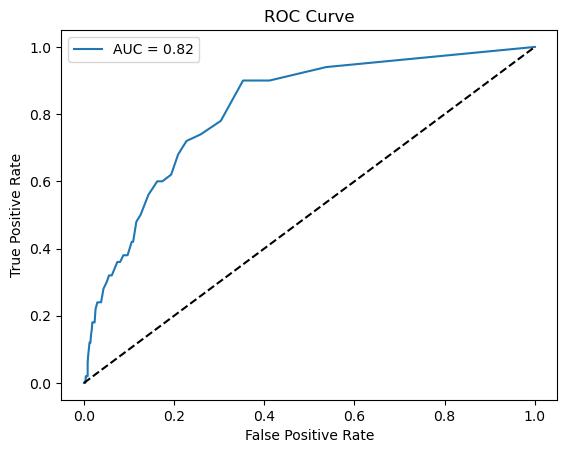

In [11]:
# Make predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]  # probability for ROC curve

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


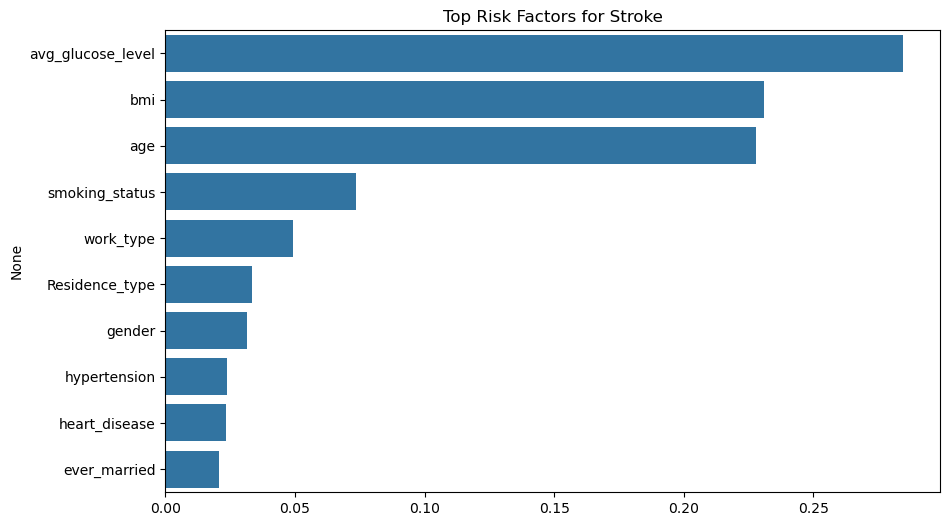

In [12]:
# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False, inplace=True)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Top Risk Factors for Stroke")
plt.show()


In [13]:
# Example new patient
new_patient = pd.DataFrame({
    'gender':[1],              # encoded
    'age':[65],
    'hypertension':[0],
    'heart_disease':[1],
    'ever_married':[1],
    'work_type':[2],
    'Residence_type':[0],
    'avg_glucose_level':[105],
    'bmi':[28],
    'smoking_status':[2]
})

# Scale numeric features
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
new_patient[numeric_cols] = scaler.transform(new_patient[numeric_cols])

# Predict
risk = rf_model.predict(new_patient)[0]
probability = rf_model.predict_proba(new_patient)[0][1]

print(f"Stroke Risk Prediction: {'Yes' if risk==1 else 'No'}")
print(f"Probability of Stroke: {probability*100:.2f}%")


Stroke Risk Prediction: No
Probability of Stroke: 9.00%


In [14]:
# Example for gender
le = LabelEncoder()
le.fit(data['gender'])  # fit on training data
print(list(le.classes_))  # shows original categories
print(list(le.transform(le.classes_)))  # shows their numeric codes


[np.int64(0), np.int64(1), np.int64(2)]
[np.int64(0), np.int64(1), np.int64(2)]


In [15]:
# 1️⃣ Enter patient details here (text values are fine)
new_patient_text = pd.DataFrame({
    'gender': ['Male'],           # 'Male', 'Female', or 'Other'
    'age': [66],                  # age in years
    'hypertension': [0],          # 0 = No, 1 = Yes
    'heart_disease': [1],         # 0 = No, 1 = Yes
    'ever_married': ['Yes'],      # 'Yes' or 'No'
    'work_type': ['Private'],     # 'Private', 'Self-employed', 'Govt_job', 'Never_worked', 'children'
    'Residence_type': ['Urban'],  # 'Urban' or 'Rural'
    'avg_glucose_level': [105],   # numeric
    'bmi': [28],                  # numeric
    'smoking_status': ['never smoked']  # 'never smoked', 'formerly smoked', 'smokes', 'Unknown'
})

# 2️⃣ Encode categorical columns the same way as training data
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(data[col])  # fit on full dataset
    new_patient_text[col] = le.transform(new_patient_text[col])

# 3️⃣ Scale numeric columns
new_patient_text[numeric_cols] = scaler.transform(new_patient_text[numeric_cols])

# 4️⃣ Predict stroke risk
risk = rf_model.predict(new_patient_text)[0]
probability = rf_model.predict_proba(new_patient_text)[0][1]

print(f"Stroke Risk Prediction: {'Yes' if risk==1 else 'No'}")
print(f"Probability of Stroke: {probability*100:.2f}%")

ValueError: invalid literal for int() with base 10: 'Male'

In [16]:
# Fit LabelEncoders on training data
encoders = {}  # dictionary to save each encoder
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(data[col])  # fit on full dataset
    data[col] = le.transform(data[col])
    encoders[col] = le  # save the encoder


In [17]:
# New patient in text format
new_patient_text = pd.DataFrame({
    'gender': ['Male'],
    'age': [66],
    'hypertension': [0],
    'heart_disease': [1],
    'ever_married': ['Yes'],
    'work_type': ['Private'],
    'Residence_type': ['Urban'],
    'avg_glucose_level': [105],
    'bmi': [28],
    'smoking_status': ['never smoked']
})

# Use the saved encoders from training
for col in categorical_cols:
    le = encoders[col]  # get fitted encoder
    new_patient_text[col] = le.transform(new_patient_text[col])

# Scale numeric columns
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
new_patient_text[numeric_cols] = scaler.transform(new_patient_text[numeric_cols])

# Predict
risk = rf_model.predict(new_patient_text)[0]
probability = rf_model.predict_proba(new_patient_text)[0][1]

print(f"Stroke Risk Prediction: {'Yes' if risk==1 else 'No'}")
print(f"Probability of Stroke: {probability*100:.2f}%")


ValueError: invalid literal for int() with base 10: 'Male'

In [18]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
new_patient[numeric_cols] = scaler.transform(new_patient[numeric_cols])


In [19]:
risk = rf_model.predict(new_patient)[0]
probability = rf_model.predict_proba(new_patient)[0][1]

print(f"Stroke Risk Prediction: {'Yes' if risk==1 else 'No'}")
print(f"Probability of Stroke: {probability*100:.2f}%")


Stroke Risk Prediction: No
Probability of Stroke: 8.00%


In [20]:
# Example new patient (66 years old, male, small heart problem, used to work)
new_patient = pd.DataFrame({
    'gender': [1],              # Male
    'age': [66],
    'hypertension': [0],        # assume no hypertension
    'heart_disease': [1],       # small heart disease problem
    'ever_married': [1],        # assume married
    'work_type': [2],           # Private work (used to work)
    'Residence_type': [1],      # Urban (assumed)
    'avg_glucose_level': [105], # assumed normal
    'bmi': [28],                # assumed
    'smoking_status': [1]       # formerly smoked (assumed)
})


In [21]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
new_patient[numeric_cols] = scaler.transform(new_patient[numeric_cols])


In [22]:
risk = rf_model.predict(new_patient)[0]
probability = rf_model.predict_proba(new_patient)[0][1]

print(f"Stroke Risk Prediction: {'Yes' if risk==1 else 'No'}")
print(f"Probability of Stroke: {probability*100:.2f}%")


Stroke Risk Prediction: No
Probability of Stroke: 14.00%


In [23]:
risk = rf_model.predict(new_patient)[0]
probability = rf_model.predict_proba(new_patient)[0][1]

print(f"Stroke Risk Prediction: {'Yes' if risk==1 else 'No'}")
print(f"Probability of Stroke: {probability*100:.2f}%")


Stroke Risk Prediction: No
Probability of Stroke: 14.00%


In [24]:
from sklearn.metrics import accuracy_score

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")


Model Accuracy: 94.81%


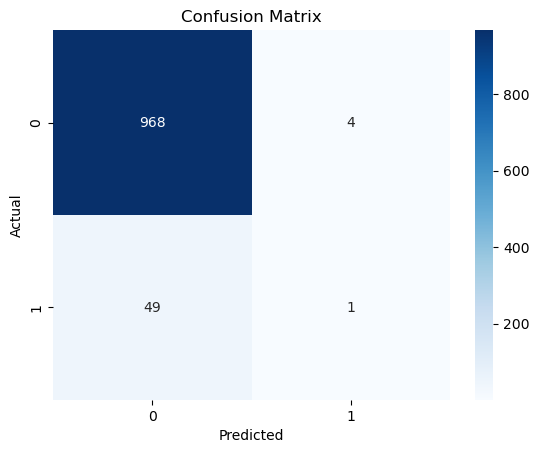

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
    from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


IndentationError: unexpected indent (1444633349.py, line 4)

In [27]:


print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.20      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.58      0.51      0.50      1022
weighted avg       0.92      0.95      0.93      1022



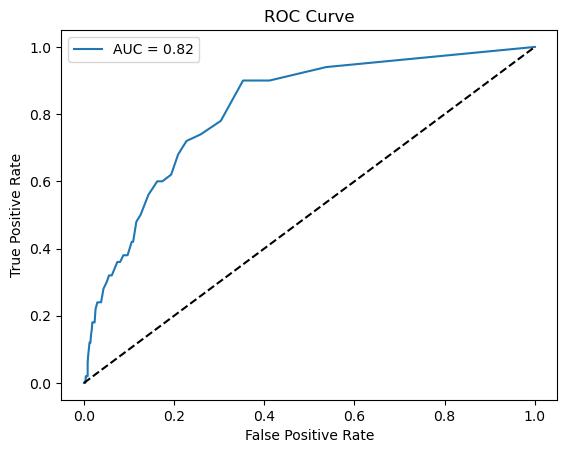

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:,1]  # probability of stroke
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [29]:
import joblib

# Save Random Forest model
joblib.dump(rf_model, "rf_model.pkl")

# Save StandardScaler
joblib.dump(scaler, "scaler.pkl")

# Save the LabelEncoders dictionary
joblib.dump(encoders, "encoders.pkl")


['encoders.pkl']

In [30]:
# 1️⃣ Define the categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# 2️⃣ Create a dictionary to save all LabelEncoders
encoders = {}

# 3️⃣ Fit LabelEncoders on text data
from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(data[col])        # Fit on original text values, e.g., 'Male', 'Female'
    data[col] = le.transform(data[col])  # Convert column to numeric for training
    encoders[col] = le       # Save encoder in dictionary

# 4️⃣ Save encoders to file
import joblib
joblib.dump(encoders, "encoders.pkl")

# ✅ Now encoders are ready for your app


['encoders.pkl']

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = data.drop('stroke', axis=1)
y = data['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save the model
joblib.dump(rf_model, "rf_model.pkl")


['rf_model.pkl']

In [32]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [33]:
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(data[col])  # <-- IMPORTANT: fit on original text values ('Male', 'Female', etc.)
    data[col] = le.transform(data[col])  # convert column to numeric for training
    encoders[col] = le

import joblib
joblib.dump(encoders, "encoders.pkl")  # save text-based encoders


['encoders.pkl']

In [34]:
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [35]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib

# Load dataset
data = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Fill missing BMI values
data['bmi'].fillna(data['bmi'].median(), inplace=True)

# Categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Create encoders dictionary
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(data[col])             # Fit on text values (Male, Female, etc.)
    data[col] = le.transform(data[col])
    encoders[col] = le

# Save encoders
joblib.dump(encoders, "encoders.pkl")

# Numeric columns
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# Features and target
X = data.drop('stroke', axis=1)
y = data['stroke']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save model and scaler
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")


C:\Users\ghady\AppData\Local\Temp\ipykernel_8948\3018467489.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bmi'].fillna(data['bmi'].median(), inplace=True)


['scaler.pkl']

In [36]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib

# Load dataset
data = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Fill missing BMI values
data['bmi'].fillna(data['bmi'].median(), inplace=True)

# Categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Create encoders dictionary
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(data[col])             # Fit on text values (Male, Female, etc.)
    data[col] = le.transform(data[col])
    encoders[col] = le

# Save encoders
joblib.dump(encoders, "encoders.pkl")

# Numeric columns
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# Features and target
X = data.drop('stroke', axis=1)
y = data['stroke']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save model and scaler
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")


C:\Users\ghady\AppData\Local\Temp\ipykernel_8948\3018467489.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bmi'].fillna(data['bmi'].median(), inplace=True)


['scaler.pkl']

In [37]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib

# Load dataset
data = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Fill missing BMI values
data['bmi'] = data['bmi'].fillna(data['bmi'].median())


# Categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Create encoders dictionary
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(data[col])             # Fit on text values (Male, Female, etc.)
    data[col] = le.transform(data[col])
    encoders[col] = le

# Save encoders
joblib.dump(encoders, "encoders.pkl")

# Numeric columns
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# Features and target
X = data.drop('stroke', axis=1)
y = data['stroke']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save model and scaler
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [38]:
# -----------------------------
# Step 0: Imports
# -----------------------------
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# -----------------------------
# Step 1: Load dataset
# -----------------------------
data = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Fill missing BMI values (avoid chained assignment warning)
data['bmi'] = data['bmi'].fillna(data['bmi'].median())

# -----------------------------
# Step 2: Encode categorical columns
# -----------------------------
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(data[col])               # fit on text values (Male, Female, etc.)
    data[col] = le.transform(data[col])
    encoders[col] = le

# Save encoders
joblib.dump(encoders, "encoders.pkl")

# -----------------------------
# Step 3: Scale numeric columns
# -----------------------------
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# -----------------------------
# Step 4: Prepare features and target
# -----------------------------
# Drop 'id' column (not needed for prediction)
X = data.drop(['stroke', 'id'], axis=1)
y = data['stroke']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# Step 5: Train Random Forest
# -----------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save model
joblib.dump(rf_model, "rf_model.pkl")

# -----------------------------
# Step 6: Optional - check accuracy
# -----------------------------
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9481409001956947

Confusion Matrix:
 [[968   4]
 [ 49   1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.20      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.58      0.51      0.50      1022
weighted avg       0.92      0.95      0.93      1022



In [39]:
# -----------------------------
# Step 6: Optional - check accuracy
# -----------------------------
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9481409001956947

Confusion Matrix:
 [[968   4]
 [ 49   1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.20      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.58      0.51      0.50      1022
weighted avg       0.92      0.95      0.93      1022



Correlation with stroke:
stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
bmi                  0.036110
smoking_status       0.028123
Residence_type       0.015458
gender               0.008929
id                   0.006388
work_type           -0.032316
Name: stroke, dtype: float64


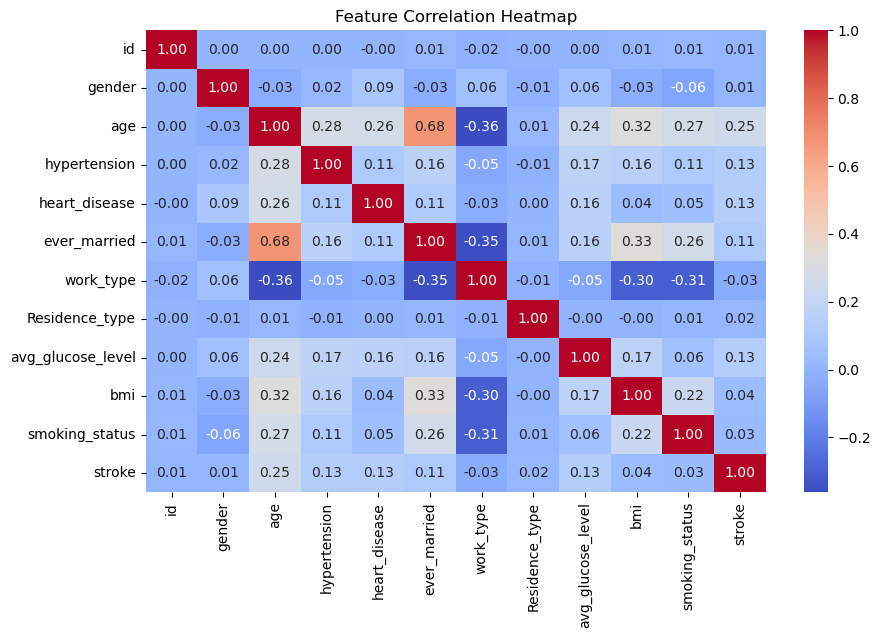

In [40]:
# Compute correlation matrix
corr_matrix = data.corr()

# Show correlation with target
print("Correlation with stroke:")
print(corr_matrix['stroke'].sort_values(ascending=False))

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


In [41]:
corr_with_target = data.corr()['stroke'].sort_values(ascending=False)
print(corr_with_target)


stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
bmi                  0.036110
smoking_status       0.028123
Residence_type       0.015458
gender               0.008929
id                   0.006388
work_type           -0.032316
Name: stroke, dtype: float64
